In [1]:
import networkx as nx
import matplotlib.pyplot as plt


In [2]:
class Map:
    def __init__(self, name, identity, way):
        self.name = name
        self.type = identity
        self.way = way
    def get_name(self, building):
        if self.type == 'Room':
            return ' '.join([building, self.name, self.type])
        elif self.type == 'Office':
            return ' '.join([building, self.name])
        elif self.type == 'Stairs' or self.type == 'Elevator':
            return ' '.join([building, self.name])
        elif self.type == 'Library':
            return self.name
        elif self.type == 'Entrance' or self.type == 'Exit':
            return ' '.join([building, self.name])
        elif self.type.casefold().find('cr') != -1:
            return ' '.join([building, self.name, self.type])
        elif self.type == 'Field' or self.type == 'Road':
            return ' '.join([building, self.name])
        elif self.type.casefold().find('electrical') != -1 or self.type.casefold().find('counseling') != -1 or self.type.casefold().find('stock') != -1:
            return ' '.join([building, self.name, self.type])
        else:
            return ' '.join([building, self.type])
    def __hash__(self):
        return hash(self.name) 

    def __repr__(self):
        return f"{self.type}: {self.name}"


In [3]:
# FIELD, ROAD, & LOBBY
lobby_entrance = ['LOBBY', Map('Pavement Entrance', 'Entrance', 1), Map('Canteen Entrance', 'Entrance', 0), Map('AGM Entrance', 'Entrance', 1)]
lobby = ['LOBBY', Map('Rest Area', 'Tables & Chairs', 1), Map('Faculty Room', 'Office', 0)]
field = ['FIELD', Map('Pavement', 'Field', 1)]
road = ['ROAD', Map('Vehicle Road', 'Road', 1)]
place = [lobby_entrance, lobby, field, road]

In [4]:
# EMM
emm_entrance = ['EMM', Map('Lobby Entrance', 'Entrance', 1), Map('Pavement Entrance', 'Entrance', 1), Map('Library Entrance', 'Entrance', 1)]
emm_floor_1 = ['EMM', Map('1st Floor Stairs 1', 'Stairs', 0), Map('101', 'Computer Lab A', 1), Map('102', 'Computer Lab B', 1), Map('103', 'MIS', 1), Map('104', 'ITE Department', 1), Map('105', 'Computer Lab C', 1), Map('1st Floor Stairs 2', 'Stairs', 0), Map('Clinic', 'Clinic', 1), Map('Storage Room', 'Storage', 1), Map('Comfort Room - Women', 'CR', 1)]
emm_floor_2 = ['EMM', Map('2nd Floor Stairs 1', 'Stairs', 0), Map('201', 'Room', 0), Map('202', 'BSCrim Office', 0), Map('IT Clinic', 'Office', 0), Map('203', 'Marketing and Office Promotion', 0), Map('204', 'SSC-SSO', 0), Map('205', 'Admission Office', 0), Map('206', 'TVET Office', 0), Map('207', 'Alumni Office', 0), Map('2nd Floor Stairs 2', 'Stairs', 0), Map('208', 'BECED Room', 0), Map('2nd Comfort Room - Men & Women', 'CR', 0)]
emm_floor_3 = ['EMM', Map('3rd Floor Stairs 1', 'Stairs', 0),  Map('301', 'Room', 0), Map('302', 'Room', 0), Map('303', 'Room', 0), Map('304', 'Room', 0), Map('305', 'TEP Coordinators Office', 0), Map('306', 'Secondary Education Simulation Room', 0), Map('307', 'Elementary Education Simulation Room', 0), Map('3rd Floor Stairs 2', 'Stairs', 0), Map('308', 'Teacher Education Program', 0), Map('3rd Comfort Room - Men & Women', 'CR', 0)]
emm_floor_4 = ['EMM', Map('4th Floor Stairs 1', 'Stairs', 0), Map('401', 'CAS Lab', 0), Map('402', 'Physics Lab', 0), Map('Vacant', 'Room', 0), Map('403', 'Science Lab Control Office', 0), Map('404', 'Chemistry Lab', 0), Map('4th Floor Stairs 2', 'Stairs', 0), Map('BLIS OFFICE', 'Office', 0), Map('Theatre', 'Room', 0), Map('405', 'Room', 0), Map('406', 'International Linkages Office', 0)]
emm = [emm_entrance, emm_floor_1, emm_floor_2, emm_floor_3, emm_floor_4]

In [5]:
# EMM - LIBRARY
library_entrance = ['LIBRARY', Map('Pavement Entrance', 'Entrance', 1), Map('FGM Entrance', 'Entrance', 1), Map('EMM Entrance', 'Entrance', 1)]
library_floor_1 = ['LIBRARY', Map('Graduate School Library', 'Library', 1), Map('1st Floor Stairs', 'Stairs', 0)]
library_floor_2 = ['LIBRARY', Map('Foreign Books Library', 'Library', 0),  Map('2nd Floor Stairs', 'Stairs', 0)]
library_floor_3 = ['LIBRARY', Map('Filipino Author Library', 'Library', 0), Map('3rd Floor Stairs', 'Stairs', 0)]
library_floor_4 = ['LIBRARY', Map('Theatre', 'Theatre', 0), Map('4th Floor Stairs', 'Stairs', 0)]
library = [library_entrance, library_floor_1, library_floor_2, library_floor_3, library_floor_4]

In [6]:
# AGM
agm_entrance = ['AGM', Map('Lobby Entrance', 'Entrance', 1), Map('Road Entrance', 'Entrance', 1), Map('FGM Entrance', 'Entrance', 1), Map('School Entrance', 'Entrance', 1)]
agm_floor_1 = ['AGM', Map('School Exit', 'Exit', 1), Map('1st Floor Stairs 1', 'Stairs', 1), Map('101', 'Hydraulics Labaratory', 1), Map('102', 'Materials & Testing Labaratory', 1), Map('103', 'CBE Office', 1), Map('104', 'CAS Office', 1), Map('105', 'Guidance Office', 1), Map('106', 'Counseling Office', 1), Map('107', 'Room', 1), Map('Canteen', 'Canteen', 1), Map('1st Floor Stairs 2', 'Stairs', 0), Map('Bookstore & Printing Office', 'Bookstore', 1)]
agm_floor_2 = ['AGM', Map('2nd Floor Stairs 2', 'Stairs', 0), Map('200', 'Electrical Room', 0,), Map('201', 'Customs Admin Simulation Room', 0,), Map('202', 'Room', 0,), Map('203', 'Criminology Intern Unit', 0,), Map('204', 'General Education Program', 0,), Map('205', 'Engineering Faculty', 0,), Map('206', 'Room', 0,), Map('Observation', 'Room', 0,), Map('207', 'Psyche Lab', 0,), Map('208', 'Room', 0,), Map('209', 'Engineering Program', 0,), Map('210', 'Room', 0,), Map('211', 'Room', 0,), Map('212', 'AB English Simulation', 0,), Map('213', 'Communication Hub', 0,), Map('214', 'Mass Communication Room', 0,), Map('2nd Floor Stairs 1', 'Stairs', 0), Map('216', 'ETEEAP Office', 0)]
agm = [agm_entrance, agm_floor_1, agm_floor_2]

In [7]:
# FGM
fgm_entrance = ['FGM', Map('Library Entrance', 'Entrance', 1), Map('Pavement Entrance', 'Entrance', 1), Map('AGM Entrance', 'Entrance', 1)]
fgm_floor_1 = ['FGM', Map('1st Floor Stairs 1', 'Stairs', 1), Map('101', 'Male CR', 1), Map('102', 'Faculty & Staff CR', 1), Map('103', 'PWD CR', 1), Map('104', 'Registrar\'s Office', 1), Map('105', 'Finance Office', 1), Map('1st Floor Elevator', 'Elevator', 1), Map('Cashier', 'Cashier', 1), Map('106', 'Academic Affairs Office', 1), Map('107', 'Electrical Room', 1), Map('108', 'Conference Room', 1), Map('109', 'REEDO', 1), Map('1st Floor Stairs 2', 'Stairs', 1)]
fgm_floor_2 = ['FGM', Map('MO1', 'Admin Office', 0), Map('2nd Floor Stairs 1', 'Stairs', 0), Map('201', 'CR Men', 1), Map('202', 'Nursing Skills Lab 1', 1), Map('203', 'Nursing Skills Lab 2', 1), Map('2nd Floor Elevator', 'Elevator', 1), Map('204', 'COAHS Dean\'s Office', 1), Map('205', 'Nursing Skills Lab 3', 1), Map('206', 'Anatomy Lab', 1), Map('207', '(BSHM-BSTM-BSOA-REM) Simulation Room', 1), Map('BSOA-BSHM-BSTM-BSREM Office', 'Office', 1), Map('209', 'Electrical Room', 1), Map('210', 'Instrumentation Room and Pharma Lab Extension', 1), Map('211', 'Nursing Skills Lab 4', 1), Map('212', 'CR Women', 1), Map('2nd Floor Stairs 2', 'Stairs', 0)]
fgm_floor_3 = ['FGM', Map('3rd Floor Stairs 1', 'Stairs', 0), Map('301', 'CR Men', 1), Map('302', 'Room', 1), Map('303', 'Room', 1), Map('3rd Floor Elevator', 'Elevator', 1), Map('Records', 'Stock Room', 1), Map('306', 'Room', 1), Map('307', 'Room', 1), Map('308', 'Room', 1), Map('3rd Floor', 'Electrical Room', 1),  Map('3rd Floor', 'Counseling Room', 1),  Map('309', 'Room', 1),  Map('311', 'Room', 1),  Map('312', 'Room', 1),  Map('313', 'CR Women', 1), Map('3rd Floor Stairs 2', 'Stairs', 0)]
fgm_floor_4 = ['FGM', Map('4th Floor Stairs 1', 'Stairs', 0), Map('401', 'CR Men', 1), Map('402', 'Room', 1), Map('403', 'Room', 1), Map('4th Floor Elevator', 'Elevator', 1), Map('405', 'Room', 1), Map('406', 'Room', 1), Map('407', 'Stock Room', 1), Map('408', 'Electrical Room', 1), Map('409', 'Room', 1), Map('410', 'Room', 1), Map('411', 'CR Women', 1), Map('4th Floor Stairs 2', 'Stairs', 0)]
fgm_floor_5 = ['FGM', Map('5th Floor Stairs 1', 'Stairs', 0), Map('501', 'CR Men', 1), Map('502', 'Criminology Lab', 1), Map('503', 'Room', 1), Map('5th Floor Elevator', 'Elevator', 1), Map('Interrogation', 'Room', 1), Map('506', 'Dark Room Forensic Photography', 1), Map('507', 'Crime Scene Room', 1), Map('508', 'Faculty Lounge', 1), Map('509', 'Court Room', 1), Map('510', 'Room', 1), Map('511', 'Electrical Room', 1), Map('512', 'Room', 1), Map('513', 'Room', 1), Map('514', 'CR Women', 1), Map('5th Floor Stairs 2', 'Stairs', 0)]
fgm_floor_6 = ['FGM', Map('6th Floor Stairs 1', 'Stairs', 0), Map('601', 'CR Men', 1), Map('602', 'Room', 1), Map('603', 'Room', 1), Map('6th Floor Elevator', 'Elevator', 1), Map('604', 'Room', 1), Map('605', 'Room', 1), Map('606', 'Room', 1), Map('607', 'Room', 1), Map('608', 'Room', 1), Map('609', 'Electrical Room', 1), Map('610', 'Room', 1), Map('611', 'Room', 1), Map('612', 'CR Women', 1), Map('6th Floor Stairs 2', 'Stairs', 0)]
fgm = [fgm_entrance, fgm_floor_1, fgm_floor_2, fgm_floor_3, fgm_floor_4, fgm_floor_5, fgm_floor_6]

In [8]:
rmmc = [place, emm, library, agm, fgm]

In [9]:
G = nx.Graph()
for place in rmmc:
    for room in place:
        temp = room[0]
        room.remove(temp)
        for i in room:
                G.add_node(i.get_name(temp), data=i)


In [10]:
for node in G.nodes:
    print(node)

LOBBY Pavement Entrance
LOBBY Canteen Entrance
LOBBY AGM Entrance
LOBBY Tables & Chairs
LOBBY Faculty Room
FIELD Pavement
ROAD Vehicle Road
EMM Lobby Entrance
EMM Pavement Entrance
EMM Library Entrance
EMM 1st Floor Stairs 1
EMM Computer Lab A
EMM Computer Lab B
EMM MIS
EMM ITE Department
EMM Computer Lab C
EMM 1st Floor Stairs 2
EMM Clinic
EMM Storage
EMM Comfort Room - Women CR
EMM 2nd Floor Stairs 1
EMM 201 Room
EMM 202 BSCrim Office
EMM IT Clinic
EMM Marketing and Office Promotion
EMM SSC-SSO
EMM Admission Office
EMM TVET Office
EMM Alumni Office
EMM 2nd Floor Stairs 2
EMM BECED Room
EMM 2nd Comfort Room - Men & Women CR
EMM 3rd Floor Stairs 1
EMM 301 Room
EMM 302 Room
EMM 303 Room
EMM 304 Room
EMM TEP Coordinators Office
EMM Secondary Education Simulation Room
EMM Elementary Education Simulation Room
EMM 3rd Floor Stairs 2
EMM Teacher Education Program
EMM 3rd Comfort Room - Men & Women CR
EMM 4th Floor Stairs 1
EMM CAS Lab
EMM Physics Lab
EMM Vacant Room
EMM Science Lab Control O

In [11]:
G.add_edge('FIELD Pavement', 'ROAD Vehicle Road')
G.add_edge('FIELD Pavement', 'EMM Pavement Entrance')
G.add_edge('FIELD Pavement', 'LOBBY Pavement Entrance')
G.add_edge('FIELD Pavement', 'FGM Pavement Entrance')
G.add_edge('FIELD Pavement', 'LOBBY Faculty Room')
G.add_edge('FIELD Pavement', 'LOBBY Tables & Chairs')
G.add_edge('FIELD Pavement', 'LIBRARY Pavement Entrance')
G.add_edge('ROAD Vehicle Road', 'AGM Road Entrance')
G.add_edge('ROAD Vehicle Road', 'FIELD Pavement')

G.add_edge('EMM Lobby Entrance', 'LOBBY Faculty Room')
G.add_edge('EMM Library Entrance', 'LIBRARY EMM Entrance')
G.add_edge('EMM Library Entrance', 'EMM Computer Lab C')
G.add_edge('EMM Lobby Entrance', 'EMM Computer Lab A')
G.add_edge('EMM 1st Floor Stairs 1', 'EMM Computer Lab A')
G.add_edge('EMM Computer Lab B', 'EMM Computer Lab A')
G.add_edge('EMM Computer Lab B', 'EMM Pavement Entrance')
G.add_edge('EMM Computer Lab B', 'EMM MIS')
G.add_edge('EMM MIS', 'EMM ITE Department')
G.add_edge('EMM ITE Department', 'EMM Computer Lab C')
G.add_edge('EMM EMM-Library Entrance', 'EMM Computer Lab C')
G.add_edge('EMM 1st Floor Stairs 2', 'EMM Computer Lab C')
G.add_edge('EMM 1st Floor Stairs 2', 'EMM Clinic')
G.add_edge('EMM 1st Floor Stairs 2', 'EMM Storage')
G.add_edge('EMM Comfort Room - Women CR', 'EMM Clinic')
G.add_edge('EMM 1st Floor Stairs 1', 'EMM 2nd Floor Stairs 1')
G.add_edge('EMM 1st Floor Stairs 2', 'EMM 2nd Floor Stairs 2')
G.add_edge('EMM 2nd Floor Stairs 1', 'EMM 201 Room')
G.add_edge('EMM 202 BSCrim Office', 'EMM 201 Room')
G.add_edge('EMM 202 BSCrim Office', 'EMM IT Clinic')
G.add_edge('EMM Marketing and Office Promotion', 'EMM IT Clinic')
G.add_edge('EMM Marketing and Office Promotion', 'EMM SSC/SSO')
G.add_edge('EMM Admission Office', 'EMM SSC/SSO')
G.add_edge('EMM Admission Office', 'EMM TVET Office')
G.add_edge('EMM Alumni Office', 'EMM TVET Office')
G.add_edge('EMM 2nd Floor Stairs 2', 'EMM Alumni Office')
G.add_edge('EMM 2nd Floor Stairs 2', 'EMM BECED Room')
G.add_edge('EMM 2nd Comfort Room - Men & Women CR', 'EMM BECED Room')
G.add_edge('EMM 3rd Floor Stairs 1', 'EMM 2nd Floor Stairs 1')
G.add_edge('EMM 3rd Floor Stairs 2', 'EMM 2nd Floor Stairs 2')
G.add_edge('EMM 3rd Floor Stairs 1', 'EMM 301 Room')
G.add_edge('EMM 302 Room', 'EMM 301 Room')
G.add_edge('EMM 302 Room', 'EMM 303 Room')
G.add_edge('EMM 304 Room', 'EMM 303 Room')
G.add_edge('EMM 304 Room', 'EMM TEP Coordinators Office')
G.add_edge('EMM Secondary Education Simulation Room', 'EMM TEP Coordinators Office')
G.add_edge('EMM Secondary Education Simulation Room', 'EMM Elementary Education Simulation Room')
G.add_edge('EMM 3rd Floor Stairs 2', 'EMM Elementary Education Simulation Room')
G.add_edge('EMM 3rd Floor Stairs 2', 'EMM Teacher Education Program')
G.add_edge('EMM 3rd Comfort Room - Men & Women CR', 'EMM Teacher Education Program')
G.add_edge('EMM 3rd Floor Stairs 1', 'EMM 4th Floor Stairs 1')
G.add_edge('EMM 3rd Floor Stairs 2', 'EMM 4th Floor Stairs 2')
G.add_edge('EMM 4th Floor Stairs 1', 'EMM CAS Lab')
G.add_edge('EMM Physics Lab', 'EMM CAS Lab')
G.add_edge('EMM Physics Lab', 'EMM Vacant Room')
G.add_edge('EMM Science Lab Control Office', 'EMM Vacant Room')
G.add_edge('EMM Science Lab Control Office', 'EMM Chemistry Lab')
G.add_edge('EMM 4th Floor Stairs 2', 'EMM Chemistry Lab')
G.add_edge('EMM 4th Floor Stairs 2', 'EMM BLIS OFFICE')
G.add_edge('EMM Theatre Room', 'EMM BLIS OFFICE')
G.add_edge('EMM 4th Floor Stairs 2', 'EMM 405 Room')
G.add_edge('EMM International Linkages Office', 'EMM 405 Room')

G.add_edge('LIBRARY FGM Entrance', 'FGM Library Entrance')
G.add_edge('LIBRARY EMM Entrance', 'Graduate School Library')
G.add_edge('LIBRARY FGM Entrance', 'Graduate School Library')
G.add_edge('Graduate School Library', 'LIBRARY Pavement Entrance')
G.add_edge('Graduate School Library', 'LIBRARY 1st Floor Stairs')
G.add_edge('LIBRARY 2nd Floor Stairs', 'LIBRARY 1st Floor Stairs')
G.add_edge('LIBRARY 2nd Floor Stairs', 'Foreign Books Library')
G.add_edge('LIBRARY 2nd Floor Stairs', 'LIBRARY 3rd Floor Stairs')
G.add_edge('Filipino Author Library', 'LIBRARY 3rd Floor Stairs')
G.add_edge('LIBRARY 4th Floor Stairs', 'LIBRARY 3rd Floor Stairs')
G.add_edge('LIBRARY 4th Floor Stairs', 'LIBRARY Theatre')

G.add_edge('LOBBY Faculty Room', 'LOBBY Tables & Chairs')
G.add_edge('LOBBY Faculty Room', 'LOBBY AGM Entrance')
G.add_edge('LOBBY Tables & Chairs', 'LOBBY AGM Entrance')
G.add_edge('LOBBY Tables & Chairs', 'LOBBY Canteen Entrance')
G.add_edge('AGM Canteen', 'LOBBY Canteen Entrance')
G.add_edge('LOBBY AGM Entrance', 'AGM Lobby Entrance')

G.add_edge('AGM 1st Floor Stairs 2', 'AGM Lobby Entrance')
G.add_edge('AGM 1st Floor Stairs 2', 'AGM 2nd Floor Stairs 2')
G.add_edge('AGM 2nd Floor Stairs 2', 'AGM Electrical Room')
G.add_edge('AGM 200 Electrical Room', 'AGM Customs Admin Simulation Room')
G.add_edge('AGM Customs Admin Simulation Room', 'AGM 202 Room')
G.add_edge('AGM 203 Criminology Intern Unit', 'AGM 202 Room')
G.add_edge('AGM General Education Program', 'AGM 203 Criminology Intern Unit')
G.add_edge('AGM General Education Program', 'AGM Engineering Faculty')
G.add_edge('AGM 206 Room', 'AGM Engineering Faculty')
G.add_edge('AGM 206 Room', 'AGM Observation Room')
G.add_edge('AGM Psyche Lab', 'AGM Observation Room')
G.add_edge('AGM Psyche Lab', 'AGM 208 Room')
G.add_edge('AGM Psyche Lab', 'AGM 210 Room')
G.add_edge('AGM Engineering Program', 'AGM 210 Room')
G.add_edge('AGM Engineering Program', 'AGM 211 Room')
G.add_edge('AGM AB English Simulation', 'AGM 211 Room')
G.add_edge('AGM AB English Simulation', 'AGM Communication Hub')
G.add_edge('AGM Mass Communication Room', 'AGM Communication Hub')
G.add_edge('AGM Lobby Entrance', 'AGM Canteen')
G.add_edge('AGM Canteen', 'AGM 1st Floor Stairs 2')
G.add_edge('AGM 1st Floor Stairs 1', 'AGM Bookstore')
G.add_edge('AGM FGM Entrance', 'AGM Bookstore')
G.add_edge('AGM Road Entrance', 'AGM 1st Floor Stairs 1')
G.add_edge('AGM Hydraulics Labaratory', 'AGM 1st Floor Stairs 1')
G.add_edge('AGM Hydraulics Labaratory', 'AGM Materials & Testing Labaratory')
G.add_edge('AGM Materials & Testing Labaratory', 'AGM School Exit')
G.add_edge('AGM School Entrance', 'AGM School Exit')
G.add_edge('AGM School Entrance', 'AGM Materials & Testing Labaratory')
G.add_edge('AGM School Entrance', 'LOBBY AGM Entrance')
G.add_edge('AGM School Entrance', 'AGM CBE Office')
G.add_edge('AGM CBE Office', 'AGM CAS Office')
G.add_edge('AGM CAS Office', 'AGM 106 Counseling Office')
G.add_edge('AGM Guidance Office', 'AGM Canteen')
G.add_edge('AGM Guidance Office', 'AGM 106 Counseling Office')
G.add_edge('AGM 107 Room', 'AGM Canteen')
G.add_edge('AGM 107 Room', 'AGM Guidance Office')
G.add_edge('AGM 1st Floor Stairs 1', 'AGM 2nd Floor Stairs 1')
G.add_edge('AGM 2nd Floor Stairs 1', 'AGM ETEEAP Office')
G.add_edge('AGM 2nd Floor Stairs 1', 'AGM Mass Communication Room')
G.add_edge('AGM Canteen', 'AGM Guidance Office')

G.add_edge('FGM AGM Entrance', 'AGM FGM Entrance')
G.add_edge('FGM Library Entrance', 'FGM 1st Floor Stairs 1')
G.add_edge('FGM Library Entrance', 'FGM 101 Male CR')
G.add_edge('FGM Library Entrance', 'FGM 102 Faculty & Staff CR')
G.add_edge('FGM Library Entrance', 'FGM 103 PWD CR')
G.add_edge('FGM Library Entrance', 'FGM Registrar\'s Office')
G.add_edge('FGM Finance Office', 'FGM Registrar\'s Office')
G.add_edge('FGM Finance Office', 'FGM 1st Floor Elevator')
G.add_edge('FGM Cashier', 'FGM 1st Floor Elevator')
G.add_edge('FGM Cashier', 'FGM Academic Affairs Office')
G.add_edge('FGM 107 Electrical Room', 'FGM Academic Affairs Office')
G.add_edge('FGM 107 Electrical Room', 'FGM Conference Room')
G.add_edge('FGM Conference Room', 'FGM REEDO')
G.add_edge('FGM 1st Floor Stairs 2', 'FGM AGM Entrance')
G.add_edge('FGM AGM Entrance', 'FGM REEDO')
G.add_edge('FGM AGM Entrance', 'FGM 1st Floor Stairs 2')
G.add_edge('FGM Pavement Entrance', 'FGM REEDO')
G.add_edge('FGM Pavement Entrance', 'FGM 1st Floor Stairs 1')
G.add_edge('FGM Pavement Entrance', 'FGM 1st Floor Stairs 2')
G.add_edge('FGM Pavement Entrance', 'FGM 101 Male CR')
G.add_edge('FGM Pavement Entrance', 'FGM 102 Faculty & Staff CR')
G.add_edge('FGM Pavement Entrance', 'FGM 103 PWD CR')
G.add_edge('FGM Pavement Entrance', 'FGM Registrar\'s Office')
G.add_edge('FGM Admin Office', 'FGM 1st Floor Stairs 1')
G.add_edge('FGM Admin Office', 'FGM 2nd Floor Stairs 1')
G.add_edge('FGM 2nd Floor Stairs 2', 'FGM 1st Floor Stairs 2')
G.add_edge('FGM 201 CR Men', 'FGM 2nd Floor Stairs 1')
G.add_edge('FGM 201 CR Men', 'FGM Nursing Skills Lab 1')
G.add_edge('FGM Nursing Skills Lab 1', 'FGM 2nd Floor Stairs 1')
G.add_edge('FGM Nursing Skills Lab 1', 'FGM Nursing Skills Lab 2')
G.add_edge('FGM 2nd Floor Elevator', 'FGM Nursing Skills Lab 2')
G.add_edge('FGM 2nd Floor Elevator', 'FGM COAHS Dean\'s Office')
G.add_edge('FGM Nursing Skills Lab 3', 'FGM COAHS Dean\'s Office')
G.add_edge('FGM 2nd Floor Elevator', 'FGM Anatomy Lab')
G.add_edge('FGM Nursing Skills Lab 2', 'FGM Anatomy Lab')
G.add_edge('FGM (BSHM/BSTM/BSOA/REM) Simulation Room', 'FGM Anatomy Lab')
G.add_edge('FGM (BSHM/BSTM/BSOA/REM) Simulation Room', 'FGM BSOA/BSHM/BSTM/BSREM Office')
G.add_edge('FGM 209 Electrical Room', 'FGM BSOA/BSHM/BSTM/BSREM Office')
G.add_edge('FGM Instrumentation Room and Pharma Lab Extension', 'FGM 209 Electrical Room')
G.add_edge('FGM Instrumentation Room and Pharma Lab Extension', 'FGM Nursing Skills Lab 4')
G.add_edge('FGM 2nd Floor Stairs 2', 'FGM Nursing Skills Lab 4')
G.add_edge('FGM 2nd Floor Stairs 2', 'FGM 212 CR Women')
G.add_edge('FGM Nursing Skills Lab 4', 'FGM 212 CR Women')
G.add_edge('FGM 3rd Floor Stairs 2', 'FGM 2nd Floor Stairs 2')
G.add_edge('FGM 2nd Floor Stairs 1', 'FGM 3rd Floor Stairs 1')
G.add_edge('FGM 3rd Floor Stairs 1', 'FGM 301 CR Men')
G.add_edge('FGM 301 CR Men', 'FGM 302 Room')
G.add_edge('FGM 3rd Floor Stairs 1', 'FGM 302 Room')
G.add_edge('FGM 303 Room', 'FGM 302 Room')
G.add_edge('FGM 303 Room', 'FGM 3rd Floor Elevator')
G.add_edge('FGM Records Stock RoomFGM Stock Room', 'FGM 3rd Floor Elevator')
G.add_edge('FGM Records Stock Room', 'FGM 306 Room')
G.add_edge('FGM 307 Room', 'FGM 2nd Floor Elevator')
G.add_edge('FGM 307 Room', 'FGM 303 Room')
G.add_edge('FGM 307 Room', 'FGM 308 Room')
G.add_edge('FGM 309 Room', 'FGM 308 Room')
G.add_edge('FGM 309 Room', 'FGM 3rd Floor Electrical Room')
G.add_edge('FGM 3rd Floor Electrical Room', 'FGM 308 Room')
G.add_edge('FGM 3rd Floor Electrical Room', 'FGM 3rd Floor Counseling Room')
G.add_edge('FGM 311 Room', 'FGM 3rd Floor Counseling Room')
G.add_edge('FGM 312 Room', 'FGM 311 Room')
G.add_edge('FGM 312 Room', 'FGM 313 CR Women')
G.add_edge('FGM 3rd Floor Stairs 2', 'FGM 313 CR Women')
G.add_edge('FGM 3rd Floor Stairs 2', 'FGM 312 Room')
G.add_edge('FGM 3rd Floor Stairs 2', 'FGM 4th Floor Stairs 2')
G.add_edge('FGM 4th Floor Stairs 1', 'FGM 3rd Floor Stairs 1')
G.add_edge('FGM 4th Floor Stairs 1', 'FGM 401 CR Men')
G.add_edge('FGM 4th Floor Stairs 1', 'FGM 402 Room')
G.add_edge('FGM 401 CR Men', 'FGM 402 Room')
G.add_edge('FGM 403 Room', 'FGM 402 Room')
G.add_edge('FGM 403 Room', 'FGM 4th Floor Elevator')
G.add_edge('FGM 404 Room', 'FGM 4th Floor Elevator')
G.add_edge('FGM 404 Room', 'FGM 405 Room')
G.add_edge('FGM 406 Room', 'FGM 4th Floor Elevator')
G.add_edge('FGM 406 Room', 'FGM 403 Room')
G.add_edge('FGM 406 Room', 'FGM 407 Stock Room')
G.add_edge('FGM 406 Room', 'FGM 408 Electrical Room')
G.add_edge('FGM 407 Stock Room', 'FGM 408 Electrical Room')
G.add_edge('FGM 409 Room', 'FGM 408 Electrical Room')
G.add_edge('FGM 409 Room', 'FGM 410 Room')
G.add_edge('FGM 411 CR Women', 'FGM 410 Room')
G.add_edge('FGM 411 CR Women', 'FGM 4th Floor Stairs 2')
G.add_edge('FGM 410 Room', 'FGM 4th Floor Stairs 2')
G.add_edge('FGM 5th Floor Stairs 2', 'FGM 4th Floor Stairs 2')
G.add_edge('FGM 5th Floor Stairs 1', 'FGM 4th Floor Stairs 1')
G.add_edge('FGM 5th Floor Stairs 1', 'FGM 501 CR Men')
G.add_edge('FGM 5th Floor Stairs 1', 'FGM 502 Criminology Lab')
G.add_edge('FGM 501 CR Men', 'FGM 502 Criminology Lab')
G.add_edge('FGM 503 Room', 'FGM 502 Criminology Lab')
G.add_edge('FGM 503 Room', 'FGM 5th Floor Elevator')
G.add_edge('FGM 5th Floor Elevator', 'FGM Interrogation Room')
G.add_edge('FGM Interrogation Room', 'FGM Dark Room Forensic Photography')
G.add_edge('FGM 507 Crime Scene Room', 'FGM Dark Room Forensic Photography')
G.add_edge('FGM 507 Crime Scene Room', 'FGM Faculty Lounge')
G.add_edge('FGM Court Room', 'FGM Faculty Lounge')
G.add_edge('FGM Court Room', 'FGM 510 Room')
G.add_edge('FGM 511 Electrical Room', 'FGM 510 Room')
G.add_edge('FGM 512 Room', 'FGM 511 Electrical Room')
G.add_edge('FGM 512 Room', 'FGM 513 Room')
G.add_edge('FGM 514 CR Women', 'FGM 513 Room')
G.add_edge('FGM 514 CR Women', 'FGM 5th Floor Stairs 2')
G.add_edge('FGM 513 Room', 'FGM 5th Floor Stairs 2')
G.add_edge('FGM 6th Floor Stairs 2', 'FGM 5th Floor Stairs 2')
G.add_edge('FGM 6th Floor Stairs 1', 'FGM 5th Floor Stairs 1')
G.add_edge('FGM 6th Floor Stairs 1', 'FGM 601 CR Men')
G.add_edge('FGM 6th Floor Stairs 1', 'FGM 602 Room')
G.add_edge('FGM 601 CR Men', 'FGM 602 Room')
G.add_edge('FGM 603 Room', 'FGM 602 Room')
G.add_edge('FGM 603 Room', 'FGM 6th Floor Elevator')
G.add_edge('FGM 604 Room', 'FGM 6th Floor Elevator')
G.add_edge('FGM 604 Room', 'FGM 605 Room')
G.add_edge('FGM 606 Room', 'FGM 6th Floor Elevator')
G.add_edge('FGM 606 Room', 'FGM 603 Room')
G.add_edge('FGM 606 Room', 'FGM 607 Room')
G.add_edge('FGM 608 Room', 'FGM 607 Room')
G.add_edge('FGM 608 Room', 'FGM 609 Electrical Room')
G.add_edge('FGM 607 Room', 'FGM 609 Electrical Room')
G.add_edge('FGM 610 Room', 'FGM 609 Electrical Room')
G.add_edge('FGM 610 Room', 'FGM 611 Room')
G.add_edge('FGM 612 CR Women', 'FGM 611 Room')
G.add_edge('FGM 612 CR Women', 'FGM 6th Floor Stairs 2')
G.add_edge('FGM 611 Room', 'FGM 6th Floor Stairs 2')

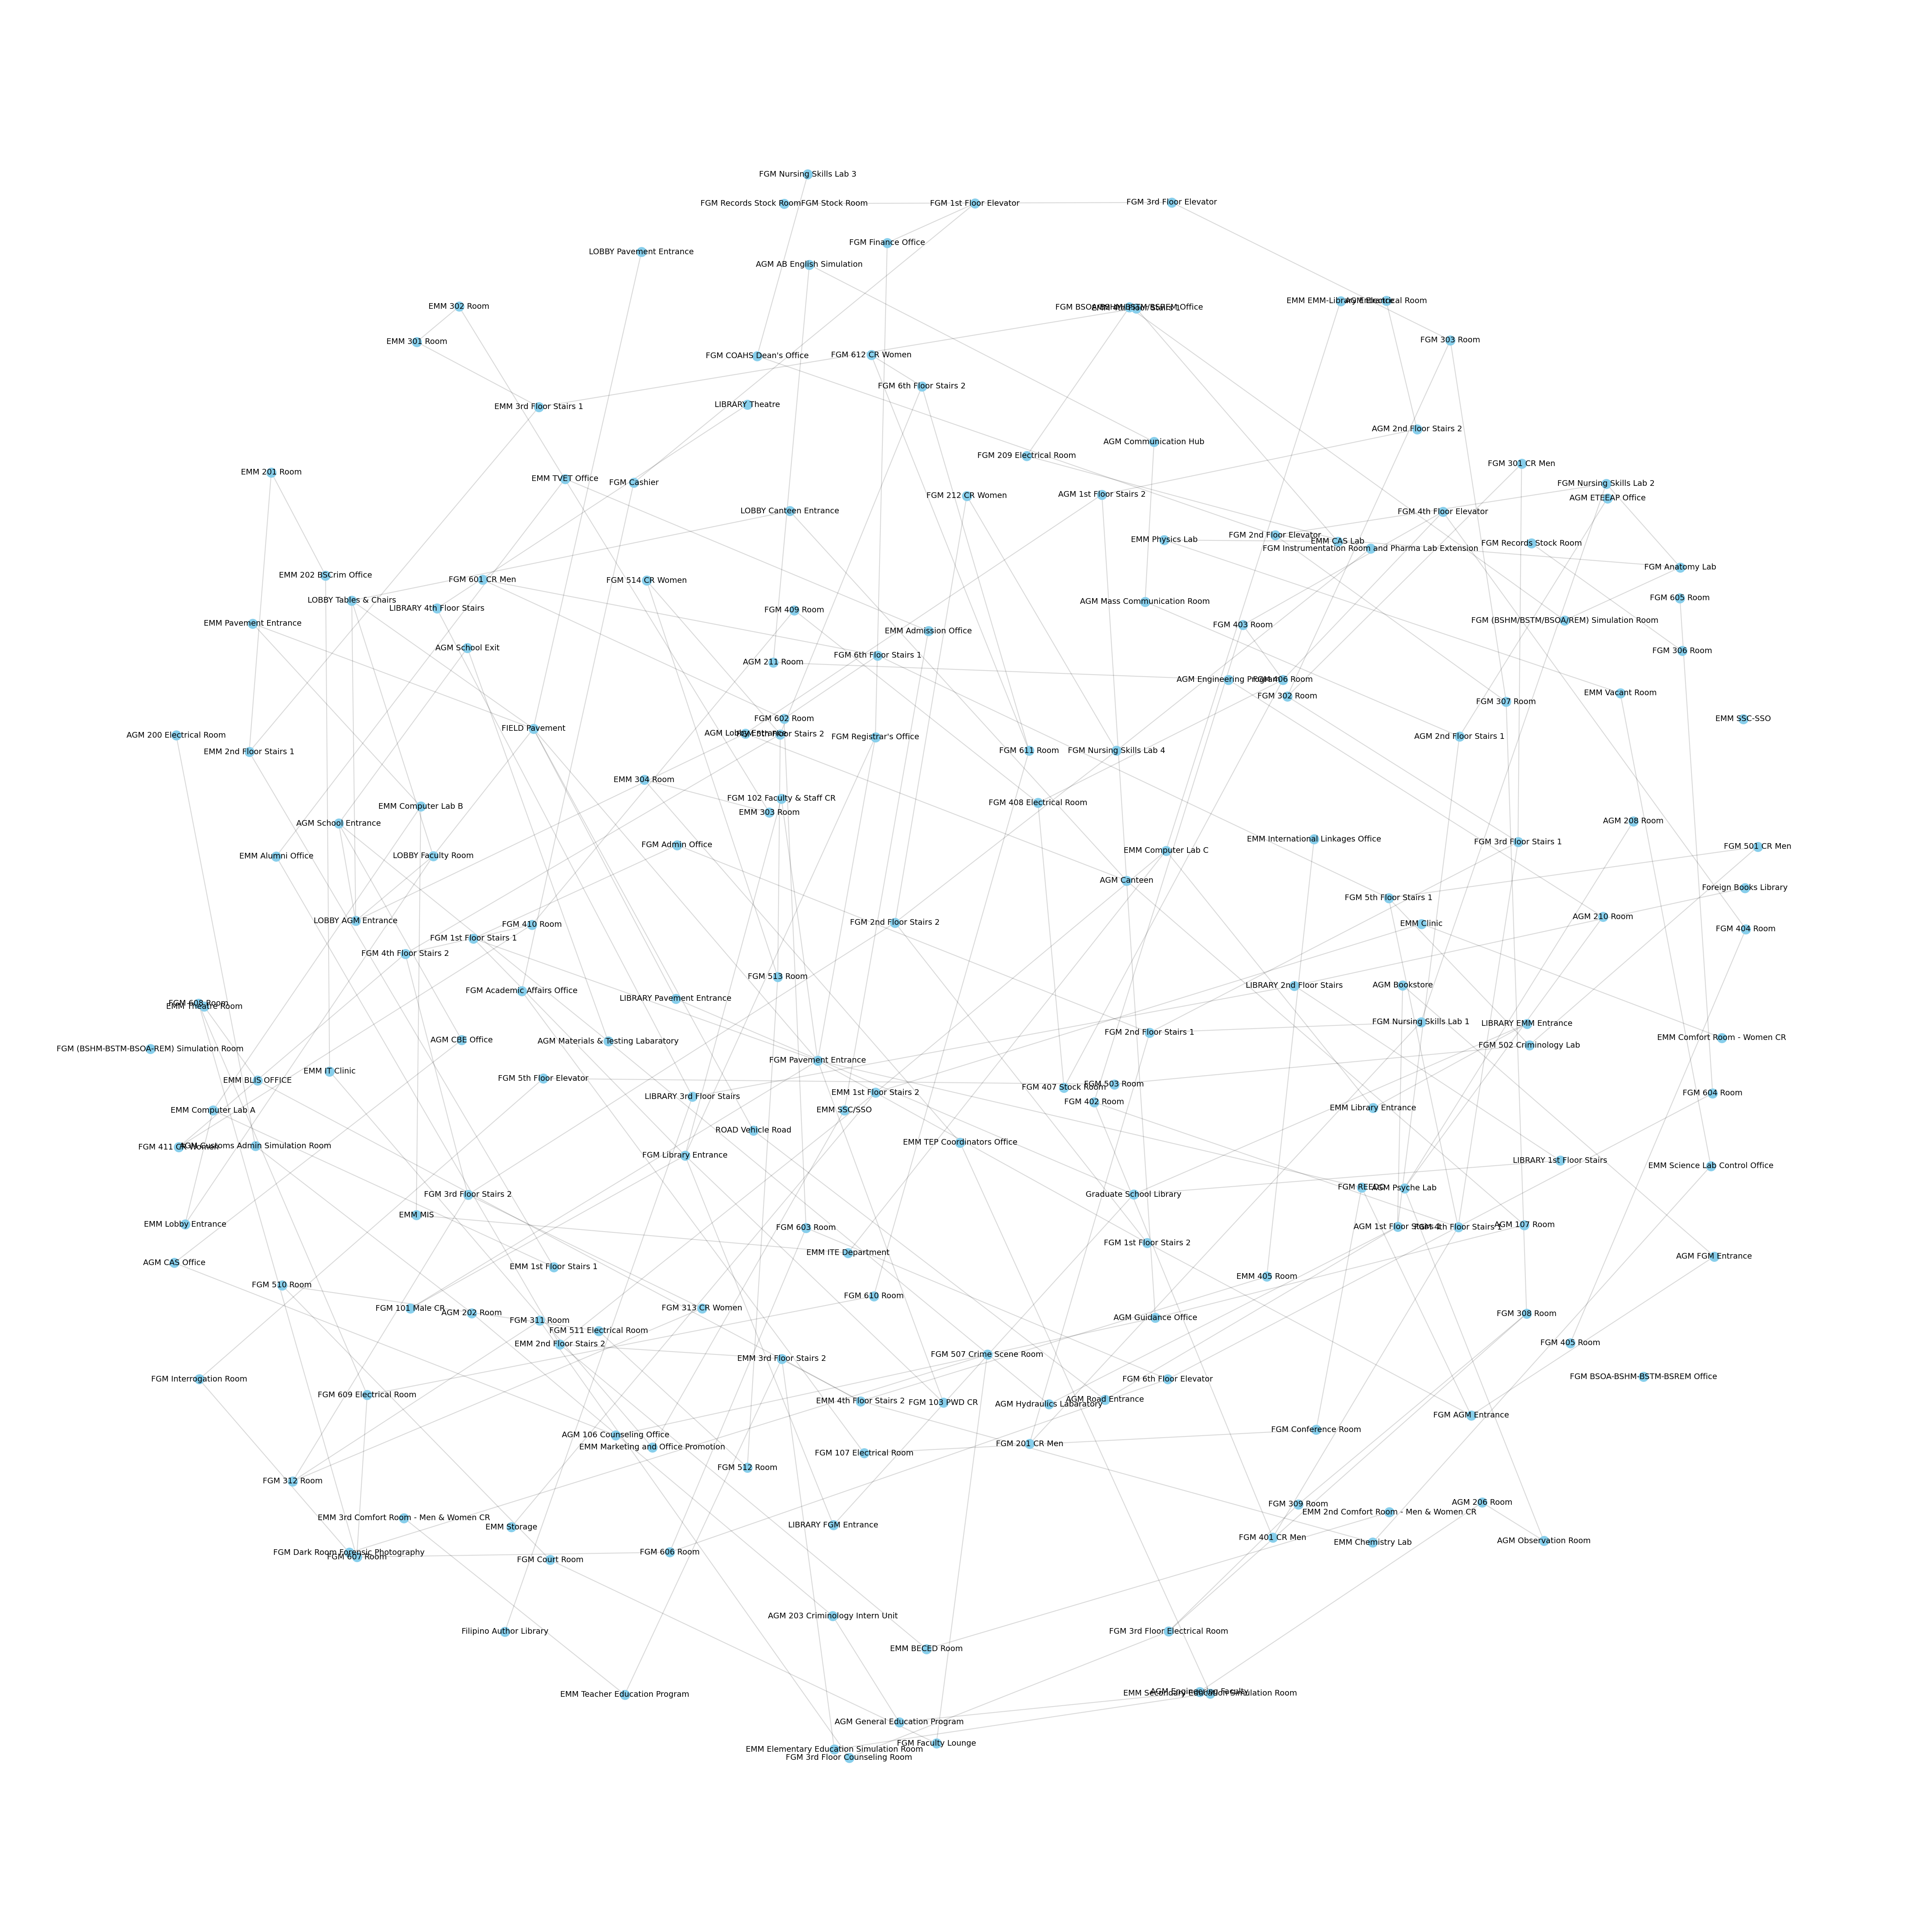

In [12]:
plt.figure(figsize=(24, 24), dpi=200)

pos = nx.spring_layout(G, k=0.8, iterations=100, seed=42)

nx.draw_networkx_edges(
    G, pos,
    alpha=0.15,
    width=0.8,
    edge_color="black"
)

nx.draw_networkx_nodes(
    G, pos,
    node_size=80,
    node_color="skyblue",
    linewidths=0
)

nx.draw_networkx_labels(
    G, pos,
    font_size=7
)

plt.axis("off")
plt.tight_layout()
plt.show()

In [13]:
path = nx.shortest_path(G, source='FGM 601 CR Men', target='EMM 405 Room')
print(path)

['FGM 601 CR Men', 'FGM 6th Floor Stairs 1', 'FGM 5th Floor Stairs 1', 'FGM 4th Floor Stairs 1', 'FGM 3rd Floor Stairs 1', 'FGM 2nd Floor Stairs 1', 'FGM Admin Office', 'FGM 1st Floor Stairs 1', 'FGM Library Entrance', 'LIBRARY FGM Entrance', 'Graduate School Library', 'LIBRARY EMM Entrance', 'EMM Library Entrance', 'EMM Computer Lab C', 'EMM 1st Floor Stairs 2', 'EMM 2nd Floor Stairs 2', 'EMM 3rd Floor Stairs 2', 'EMM 4th Floor Stairs 2', 'EMM 405 Room']
